<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico N°5
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna

A partir de las señales provistas en el repositorio PDStestbench:

- **ECG**: registro electrocardiográfico durante una prueba de esfuerzo.
- **PPG**: señal de pletismografía registrada en reposo.
- **Audio**: frase hablada por el profesor y dos silbidos de una melodía conocida.

**Se pide:**

1. Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).
2. Realizar una estimación del ancho de banda de cada señal y presentar los resultados en una tabla.

## Introducción

En este trabajo se analiza la densidad espectral de potencia (PSD) de cinco señales reales de distinta naturaleza: una señal de electrocardiograma (ECG), una señal de pletismografía (PPG) y tres señales de audio (una frase hablada y dos silbidos de melodías conocidas).

La PSD describe cómo se distribuye la potencia de una señal en función de la frecuencia, permitiendo identificar en qué regiones espectrales se concentra la mayor parte de la energía. Por ejemplo, el ECG presenta energía principalmente en bajas frecuencias debido al ritmo cardíaco, mientras que las señales de audio poseen componentes de frecuencia más elevadas.

### Métodos utilizados

Se emplean dos métodos para estimar la PSD:

**1. Periodograma ventaneado con ventana Hann**

Consiste en multiplicar la señal completa por una ventana Hann antes de calcular la FFT. Esta ventana reduce el efecto de leakage o desparramo espectral, disminuyendo la dispersión de energía hacia frecuencias vecinas. Sin embargo, al utilizar una única realización de la señal, el espectro puede presentar una alta variabilidad estadística.

**2. Método de Welch con zero padding**

El método de Welch divide la señal en segmentos parcialmente superpuestos, calcula la FFT de cada uno y promedia los resultados obtenidos. Este promediado reduce la varianza del estimador y produce espectros más suaves y estables.

Además, se aplica zero-padding mediante el parámetro `nfft`, agregando ceros al final de cada segmento antes de calcular la FFT. Esto genera una representación espectral más continua e interpolada. Sin embargo, el zero-padding no mejora la resolución espectral real, ya que no incrementa la cantidad de información contenida en la señal.


## Código y análisis

### Importaciones y carga de señales

In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio

# ECG — fs = 1000 Hz (1000 muestras por segundo)
fs_ecg = 1000
ecg_one_lead = np.load('ecg_sin_ruido.npy')
N_ecg = len(ecg_one_lead)
print(f"ECG: {N_ecg} muestras — duración: {N_ecg/fs_ecg:.1f} s")

# PPG — fs = 400 Hz
fs_ppg = 400
ppg = np.load('ppg_sin_ruido.npy')
N_ppg = len(ppg)
print(f"PPG: {N_ppg} muestras — duración: {N_ppg/fs_ppg:.1f} s")

# Audio — fs = 48000 Hz (calidad de audio estándar)
fs_audio, wav_cucaracha = sio.wavfile.read('la cucaracha.wav')
N_cucaracha = len(wav_cucaracha)
print(f"La Cucaracha: {N_cucaracha} muestras — fs: {fs_audio} Hz — duración: {N_cucaracha/fs_audio:.1f} s")

fs_silbido, wav_silbido = sio.wavfile.read('silbido.wav')
N_silbido = len(wav_silbido)
print(f"Silbido: {N_silbido} muestras — fs: {fs_silbido} Hz — duración: {N_silbido/fs_silbido:.1f} s")

fs_prueba, wav_prueba = sio.wavfile.read('prueba psd.wav')
N_prueba = len(wav_prueba)
print(f"Frase hablada: {N_prueba} muestras — fs: {fs_prueba} Hz — duración: {N_prueba/fs_prueba:.1f} s")

ECG: 30000 muestras — duración: 30.0 s
PPG: 44919 muestras — duración: 112.3 s
La Cucaracha: 144000 muestras — fs: 48000 Hz — duración: 3.0 s
Silbido: 144000 muestras — fs: 48000 Hz — duración: 3.0 s
Frase hablada: 144000 muestras — fs: 48000 Hz — duración: 3.0 s


Las señales biomédicas (ECG y PPG) tienen frecuencias de muestreo mucho menores que las de audio, ya que los fenómenos fisiológicos ocurren a frecuencias bajas. Las señales de audio tienen una frecuencia de muestreo de 48000 Hz, suficiente para capturar todo el rango auditivo humano (hasta aproximadamente 20000 Hz).

### Cálculo de PSD — Periodograma Hann y Welch con zero padding

In [2]:
# ECG
# Welch: nperseg=N//13 divide la señal en 13 segmentos aprox con superposición por defecto
# nfft=N_ecg aplica zero padding a cada segmento hasta N muestras
f_ecg, welch_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=N_ecg//13, nfft=N_ecg)
welch_ecg_db     = 10 * np.log10(welch_ecg / np.max(welch_ecg))
window_ecg       = sig.windows.hann(N_ecg)
XX_ecg           = np.fft.rfft(ecg_one_lead * window_ecg) / (N_ecg * np.mean(window_ecg))
Pxx_ecg          = 2 * np.abs(XX_ecg)**2
Pxx_ecg[0]      /= 2
ff_ecg           = np.fft.rfftfreq(N_ecg, 1/fs_ecg)
Pxx_ecg_db       = 10 * np.log10(Pxx_ecg / np.max(Pxx_ecg))

# PPG
f_ppg, welch_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=N_ppg//30, nfft=N_ppg)
welch_ppg_db     = 10 * np.log10(welch_ppg / np.max(welch_ppg))
window_ppg       = sig.windows.hann(N_ppg)
XX_ppg           = np.fft.rfft(ppg * window_ppg) / (N_ppg * np.mean(window_ppg))
Pxx_ppg          = 2 * np.abs(XX_ppg)**2
Pxx_ppg[0]      /= 2
ff_ppg           = np.fft.rfftfreq(N_ppg, 1/fs_ppg)
Pxx_ppg_db       = 10 * np.log10(Pxx_ppg / np.max(Pxx_ppg))

# La Cucaracha
f_cuc, welch_cuc = sig.welch(wav_cucaracha, fs=fs_audio, nperseg=N_cucaracha//60, nfft=N_cucaracha)
welch_cuc_db     = 10 * np.log10(welch_cuc / np.max(welch_cuc))
window_cuc       = sig.windows.hann(N_cucaracha)
XX_cuc           = np.fft.rfft(wav_cucaracha * window_cuc) / (N_cucaracha * np.mean(window_cuc))
Pxx_cuc          = 2 * np.abs(XX_cuc)**2
Pxx_cuc[0]      /= 2
ff_cuc           = np.fft.rfftfreq(N_cucaracha, 1/fs_audio)
Pxx_cuc_db       = 10 * np.log10(Pxx_cuc / np.max(Pxx_cuc))

# Silbido
f_silb, welch_silb = sig.welch(wav_silbido, fs=fs_silbido, nperseg=N_silbido//80, noverlap=1000, nfft=N_silbido)
welch_silb_db      = 10 * np.log10(welch_silb / np.max(welch_silb))
window_silb        = sig.windows.hann(N_silbido)
XX_silb            = np.fft.rfft(wav_silbido * window_silb) / (N_silbido * np.mean(window_silb))
Pxx_silb           = 2 * np.abs(XX_silb)**2
Pxx_silb[0]       /= 2
ff_silb            = np.fft.rfftfreq(N_silbido, 1/fs_silbido)
Pxx_silb_db        = 10 * np.log10(Pxx_silb / np.max(Pxx_silb))

# Frase hablada
f_pru, welch_pru = sig.welch(wav_prueba, fs=fs_prueba, nperseg=N_prueba//80, noverlap=500, nfft=N_prueba)
welch_pru_db     = 10 * np.log10(welch_pru / np.max(welch_pru))
window_pru       = sig.windows.hann(N_prueba)
XX_pru           = np.fft.rfft(wav_prueba * window_pru) / (N_prueba * np.mean(window_pru))
Pxx_pru          = 2 * np.abs(XX_pru)**2
Pxx_pru[0]      /= 2
ff_pru           = np.fft.rfftfreq(N_prueba, 1/fs_prueba)
Pxx_pru_db       = 10 * np.log10(Pxx_pru / np.max(Pxx_pru))

### PSD — ECG y PPG

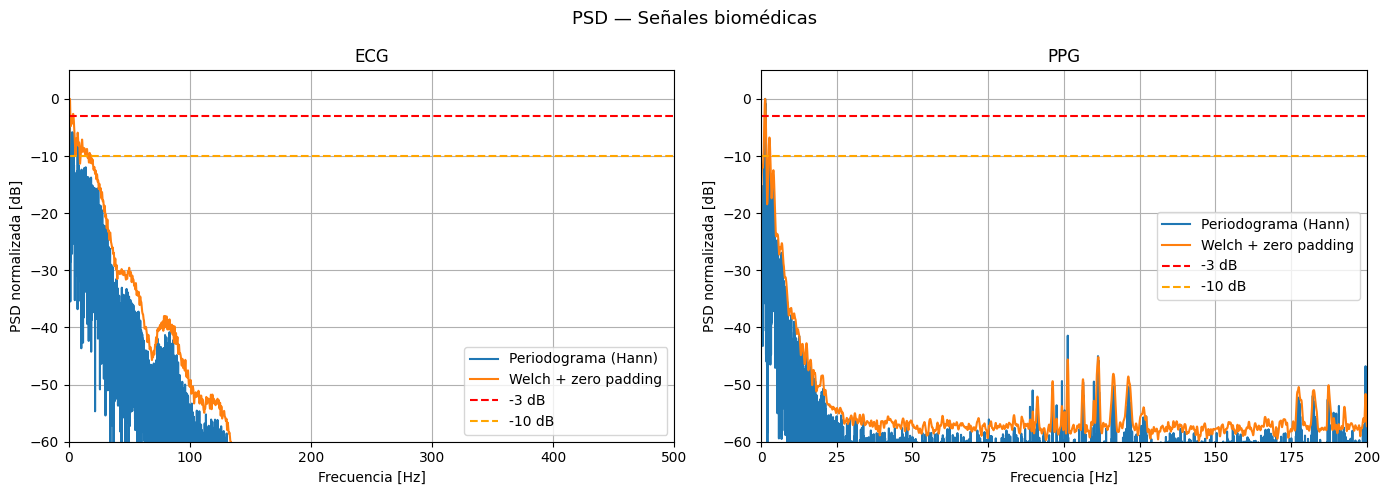

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD — Señales biomédicas', fontsize=13)

ax1.plot(ff_ecg, Pxx_ecg_db,   label='Periodograma (Hann)')
ax1.plot(f_ecg,  welch_ecg_db, label='Welch + zero padding')
ax1.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax1.axhline(y=-10, color='orange', linestyle='--', label='-10 dB')
ax1.set_title('ECG')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD normalizada [dB]')
ax1.set_xlim([0, fs_ecg/2])
ax1.set_ylim([-60, 5])
ax1.legend()
ax1.grid(True)

ax2.plot(ff_ppg, Pxx_ppg_db,   label='Periodograma (Hann)')
ax2.plot(f_ppg,  welch_ppg_db, label='Welch + zero padding')
ax2.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax2.axhline(y=-10, color='orange', linestyle='--', label='-10 dB')
ax2.set_title('PPG')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD normalizada [dB]')
ax2.set_xlim([0, fs_ppg/2])
ax2.set_ylim([-60, 5])
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


En ambas señales se nota bastante la diferencia entre los dos métodos. El periodograma con ventana Hann aparece mucho más irregular y “ruidoso”, ya que se calcula usando una sola FFT de toda la señal. Al no haber promediado, la variabilidad estadística del espectro es alta.

En cambio, el método de Welch produce curvas mucho más suaves y estables. Esto ocurre porque divide la señal en segmentos y promedia los espectros obtenidos, reduciendo el ruido estadístico. Además, el zero padding agrega puntos intermedios en frecuencia, haciendo que la curva se vea más continua visualmente.

Para este tipo de señales reales, Welch resulta más adecuado porque permite observar mejor el contenido frecuencial general sin tantas fluctuaciones.

**Análisis del ECG:**

La mayor parte de la energía del ECG se concentra en bajas frecuencias, principalmente por debajo de los 20 Hz. Esto tiene sentido porque la señal cardíaca es relativamente lenta y periódica.

**Análisis del PPG:**

En la señal PPG la energía cae mucho más rápido y gran parte del contenido útil aparece por debajo de los 4 Hz aproximadamente. Esto es coherente con la frecuencia cardíaca en reposo y con el hecho de que la PPG refleja variaciones del volumen sanguíneo, generando una señal más suave y con menos contenido armónico que el ECG.

### PSD — Señales de audio

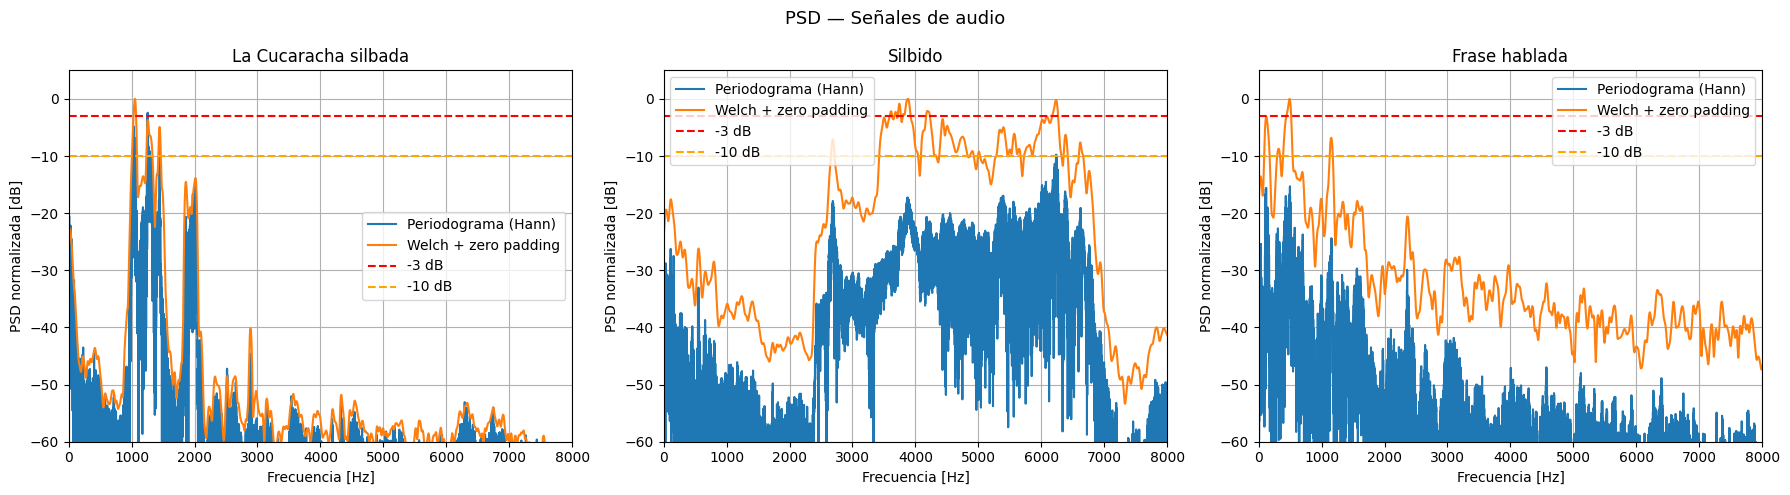

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PSD — Señales de audio', fontsize=13)

ax1.plot(ff_cuc, Pxx_cuc_db,   label='Periodograma (Hann)')
ax1.plot(f_cuc,  welch_cuc_db, label='Welch + zero padding')
ax1.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax1.axhline(y=-10, color='orange', linestyle='--', label='-10 dB')
ax1.set_title('La Cucaracha silbada')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD normalizada [dB]')
ax1.set_xlim([0, 8000])
ax1.set_ylim([-60, 5])
ax1.legend()
ax1.grid(True)

ax2.plot(ff_silb, Pxx_silb_db,   label='Periodograma (Hann)')
ax2.plot(f_silb,  welch_silb_db, label='Welch + zero padding')
ax2.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax2.axhline(y=-10, color='orange', linestyle='--', label='-10 dB')
ax2.set_title('Silbido')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD normalizada [dB]')
ax2.set_xlim([0, 8000])
ax2.set_ylim([-60, 5])
ax2.legend()
ax2.grid(True)

ax3.plot(ff_pru, Pxx_pru_db,   label='Periodograma (Hann)')
ax3.plot(f_pru,  welch_pru_db, label='Welch + zero padding')
ax3.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax3.axhline(y=-10, color='orange', linestyle='--', label='-10 dB')
ax3.set_title('Frase hablada')
ax3.set_xlabel('Frecuencia [Hz]')
ax3.set_ylabel('PSD normalizada [dB]')
ax3.set_xlim([0, 8000])
ax3.set_ylim([-60, 5])
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

Se puede ver claramente que el Welch queda mucho más suave que el periodograma en los tres casos, lo que hace más fácil identificar dónde está la energía de cada señal.

**La Cucaracha:** Se ven picos bien marcados entre 1000 y 2000 Hz, que corresponden a las notas de la melodía. Un silbido produce tonos casi puros, por eso aparecen picos bien definidos y no una curva suave. Por encima de 2500 Hz la energía cae bastante, lo que tiene sentido porque la melodía fue silbada en un registro de notas no tan agudo.

**Silbido:** Este silbido tiene energía en un rango más alto que La Cucaracha, entre 3500 y 7000 Hz aproximadamente, lo que lo hace más agudo. El espectro es más ancho y menos definido, lo que sugiere que la frecuencia varía bastante durante el silbido.

**Frase hablada:** La voz concentra su energía en frecuencias bajas, por debajo de los 500 Hz. Esto es típico de la voz humana hablando en tono normal. A diferencia de los silbidos, el espectro es más continuo y sin picos tan marcados.

## Zoom para estimación del ancho de banda

Para estimar el ancho de banda de cada señal se hace un zoom en la zona de interés usando la curva de Welch, que es la más limpia para leer.
El ancho de banda (BW) es simplemente el rango de frecuencias donde la señal tiene energía relevante. En este caso se usa el criterio de -10 dB: todo lo que está por encima de la línea naranja se considera parte del ancho de banda, y lo que cae por debajo se descarta porque ya no tiene energía significativa.
Para el ECG, el PPG y la frase hablada, que tienen energía desde frecuencias muy bajas, el BW va desde 0 Hz hasta donde la curva cruza la línea naranja por última vez. Para los silbidos es distinto porque su energía no empieza en 0 Hz sino en el medio del espectro, entonces hay que identificar el punto donde la curva sube por encima de -10 dB y el punto donde vuelve a caer, y la diferencia entre esas dos frecuencias es el BW.

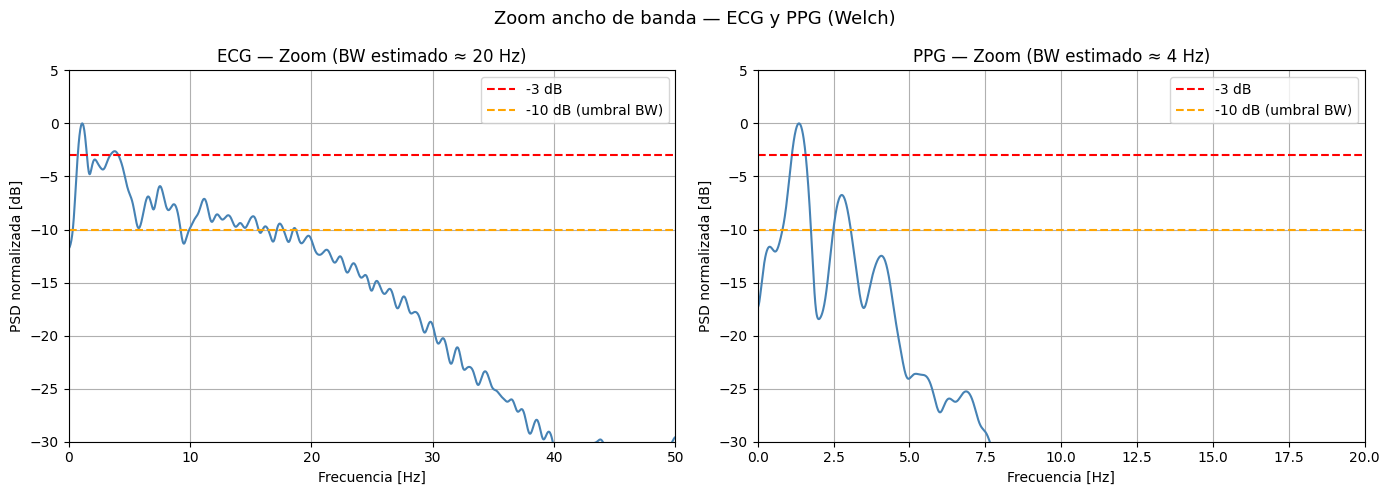

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Zoom ancho de banda — ECG y PPG (Welch)', fontsize=13)

ax1.plot(f_ecg, welch_ecg_db, color='steelblue')
ax1.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax1.axhline(y=-10, color='orange', linestyle='--', label='-10 dB (umbral BW)')
ax1.set_title('ECG — Zoom (BW estimado ≈ 20 Hz)')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD normalizada [dB]')
ax1.set_xlim([0, 50])
ax1.set_ylim([-30, 5])
ax1.legend()
ax1.grid(True)

ax2.plot(f_ppg, welch_ppg_db, color='steelblue')
ax2.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax2.axhline(y=-10, color='orange', linestyle='--', label='-10 dB (umbral BW)')
ax2.set_title('PPG — Zoom (BW estimado ≈ 4 Hz)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD normalizada [dB]')
ax2.set_xlim([0, 20])
ax2.set_ylim([-30, 5])
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

ECG: La curva cae por debajo de -10 dB cerca de los 20 Hz. Entre 0 y 10 Hz está la mayor parte de la energía, después va cayendo gradualmente. BW ≈ 20 Hz.

PPG: Cae mucho más rápido, ya a los 4 Hz está por debajo de la línea naranja. Tiene sentido porque el pulso cardíaco en reposo es muy lento. BW ≈ 4 Hz.


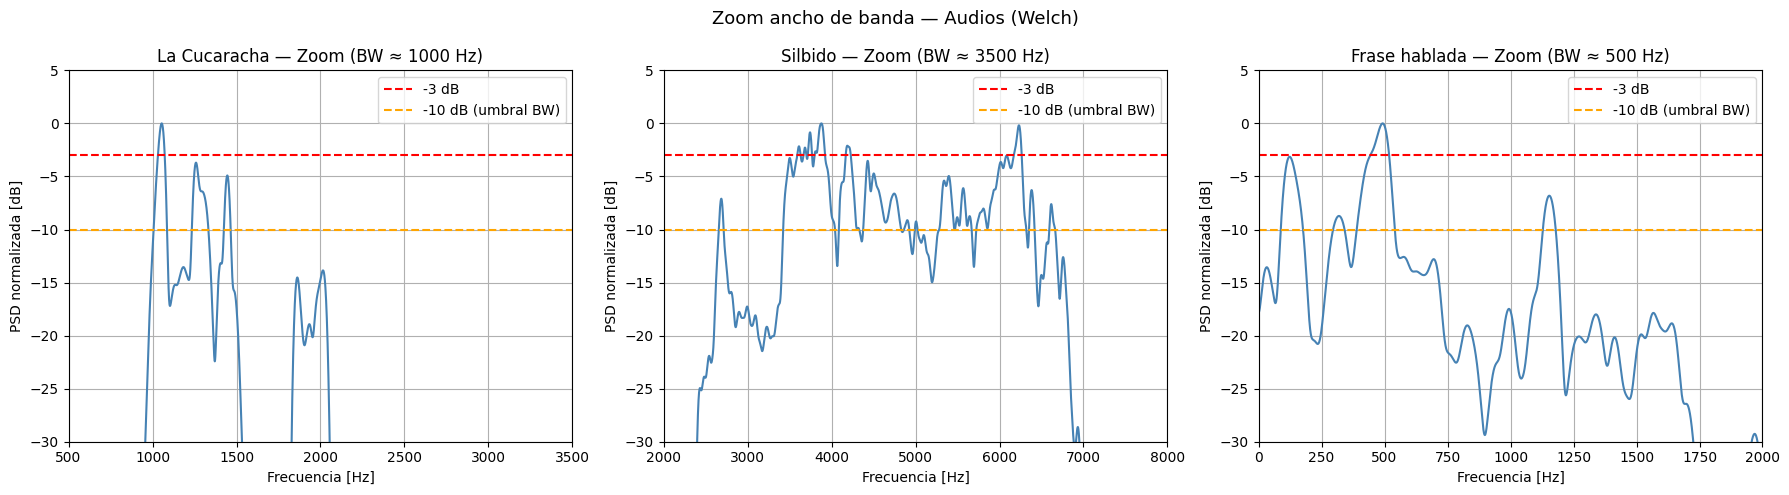

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Zoom ancho de banda — Audios (Welch)', fontsize=13)

ax1.plot(f_cuc, welch_cuc_db, color='steelblue')
ax1.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax1.axhline(y=-10, color='orange', linestyle='--', label='-10 dB (umbral BW)')
ax1.set_title('La Cucaracha — Zoom (BW ≈ 1000 Hz)')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD normalizada [dB]')
ax1.set_xlim([500, 3500])
ax1.set_ylim([-30, 5])
ax1.legend()
ax1.grid(True)

ax2.plot(f_silb, welch_silb_db, color='steelblue')
ax2.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax2.axhline(y=-10, color='orange', linestyle='--', label='-10 dB (umbral BW)')
ax2.set_title('Silbido — Zoom (BW ≈ 3500 Hz)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD normalizada [dB]')
ax2.set_xlim([2000, 8000])
ax2.set_ylim([-30, 5])
ax2.legend()
ax2.grid(True)

ax3.plot(f_pru, welch_pru_db, color='steelblue')
ax3.axhline(y=-3,  color='red',    linestyle='--', label='-3 dB')
ax3.axhline(y=-10, color='orange', linestyle='--', label='-10 dB (umbral BW)')
ax3.set_title('Frase hablada — Zoom (BW ≈ 500 Hz)')
ax3.set_xlabel('Frecuencia [Hz]')
ax3.set_ylabel('PSD normalizada [dB]')
ax3.set_xlim([0, 2000])
ax3.set_ylim([-30, 5])
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

**La Cucaracha:** los picos de energía están entre 1000 y 2000 Hz, fuera de ese rango la curva cae por debajo de -10 dB. BW ≈ 1000 Hz (de 1000 a 2000 Hz).

**Silbido:** la energía entra por encima de -10 dB cerca de los 3500 Hz y cae alrededor de los 7000 Hz. Es la señal con mayor ancho de banda de las tres, lo que indica que abarca un rango de frecuencias bastante amplio. BW ≈ 3500 Hz (de 3500 a 7000 Hz).

**Frase hablada:** la energía cae por debajo de -10 dB cerca de los 500 Hz. Es la señal de audio con menor ancho de banda, típico de la voz hablando en tono normal. BW ≈ 500 Hz (de 0 a 500 Hz).

### Tabla resumen — Ancho de banda estimado

In [7]:
print(f"  {'Señal':<20} {'f_min [Hz]':>12} {'f_max [Hz]':>12} {'BW [Hz]':>10} {'Criterio':>10}")
print(f"  {'─'*68}")
print(f"  {'ECG':<20} {0:>12} {20:>12} {20:>10} {'−10 dB':>10}")
print(f"  {'PPG':<20} {0:>12} {4:>12} {4:>10} {'−10 dB':>10}")
print(f"  {'La Cucaracha':<20} {1000:>12} {2000:>12} {1000:>10} {'−10 dB':>10}")
print(f"  {'Silbido':<20} {3500:>12} {7000:>12} {3500:>10} {'−10 dB':>10}")
print(f"  {'Frase hablada':<20} {0:>12} {500:>12} {500:>10} {'−10 dB':>10}")

  Señal                  f_min [Hz]   f_max [Hz]    BW [Hz]   Criterio
  ────────────────────────────────────────────────────────────────────
  ECG                             0           20         20     −10 dB
  PPG                             0            4          4     −10 dB
  La Cucaracha                 1000         2000       1000     −10 dB
  Silbido                      3500         7000       3500     −10 dB
  Frase hablada                   0          500        500     −10 dB


Mirando la tabla, se puede ver que cada señal tiene un ancho de banda muy distinto según su naturaleza.
El ECG y el PPG tienen los BW más chicos de todas (20 Hz y 4 Hz), lo cual tiene sentido porque son señales fisiológicas lentas relacionadas al ritmo cardíaco.
Dentro de las señales de audio, la frase hablada tiene el menor ancho de banda (500 Hz) porque la voz hablando en tono normal se concentra en frecuencias bajas. La Cucaracha silbada abarca un rango medio (1000 Hz) limitado por las notas de la melodía. Y el silbido tiene el mayor ancho de banda de todas las señales (3500 Hz) porque varía bastante de tono a lo largo del registro.

## Conclusión


Se analizó la PSD de cinco señales reales usando dos métodos: periodograma ventaneado con ventana Hann y Welch con zero padding.
En todos los casos el Welch dio un espectro más suave y fácil de interpretar que el periodograma, porque promedia múltiples segmentos y reduce el ruido estadístico. El zero padding ayuda a que el espectro se vea más continuo visualmente, aunque no mejora la resolución espectral real.
Para estimar el ancho de banda se usó el criterio de -10 dB respecto al pico, que permite identificar a ojo el rango de frecuencias donde cada señal tiene energía relevante. Los resultados tienen sentido con lo que se espera de cada señal: el ECG y el PPG tienen BW muy chico porque son fenómenos lentos, y las señales de audio tienen BW más amplio y en rangos más altos, con diferencias entre sí según el tipo de sonido.
Este análisis es útil porque permite entender qué información frecuencial tiene una señal y con qué frecuencia de muestreo mínima habría que digitalizarla para no perder nada, que es básicamente el criterio de Nyquist.